In [1]:
import pandas as pd
import matplotlib.pyplot as plt

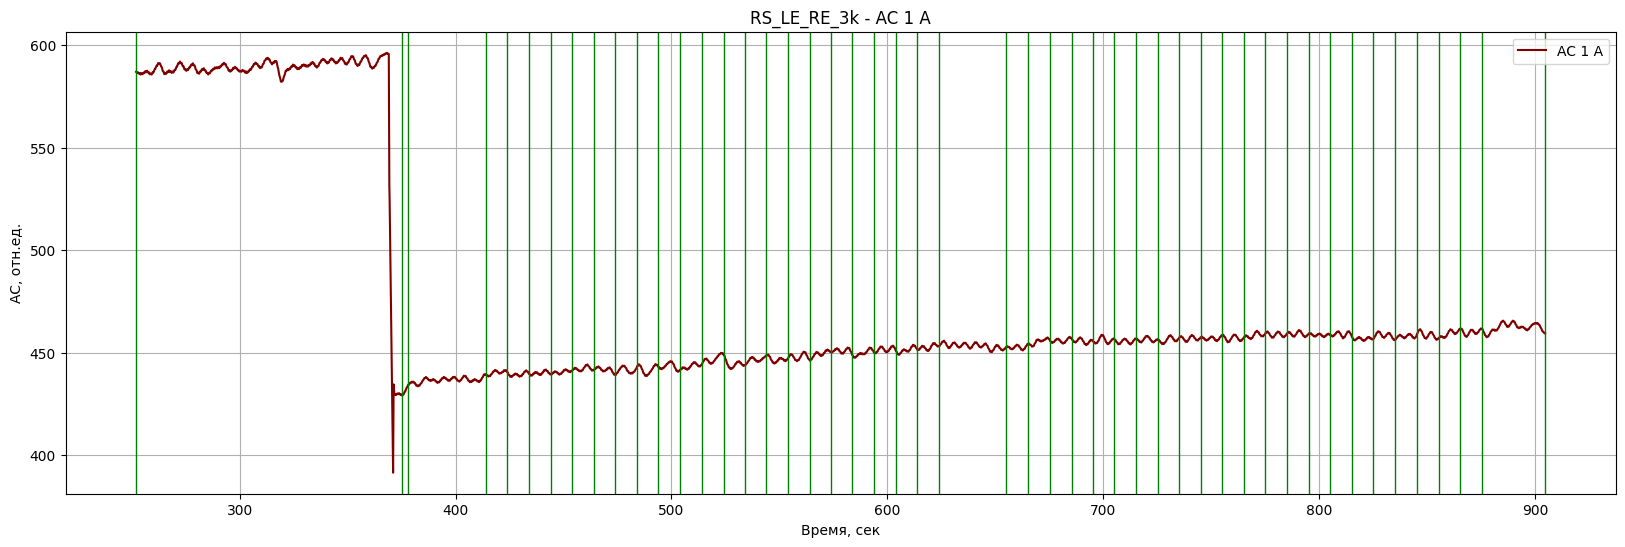

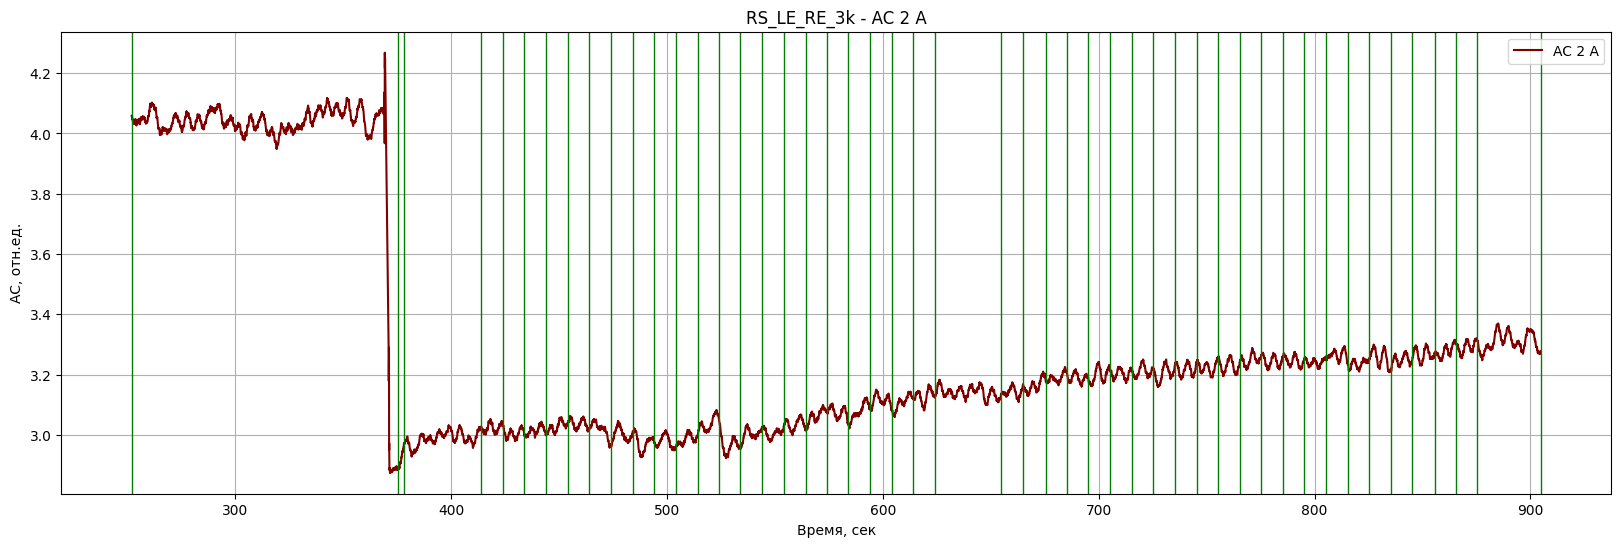

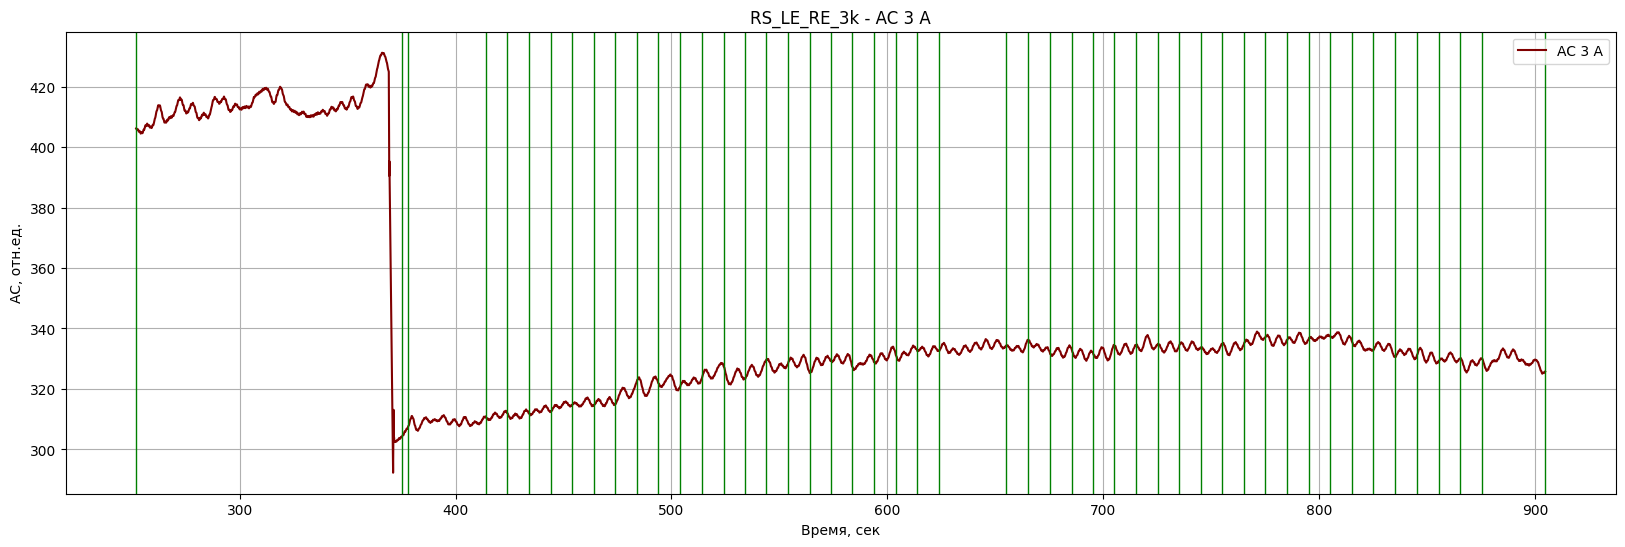

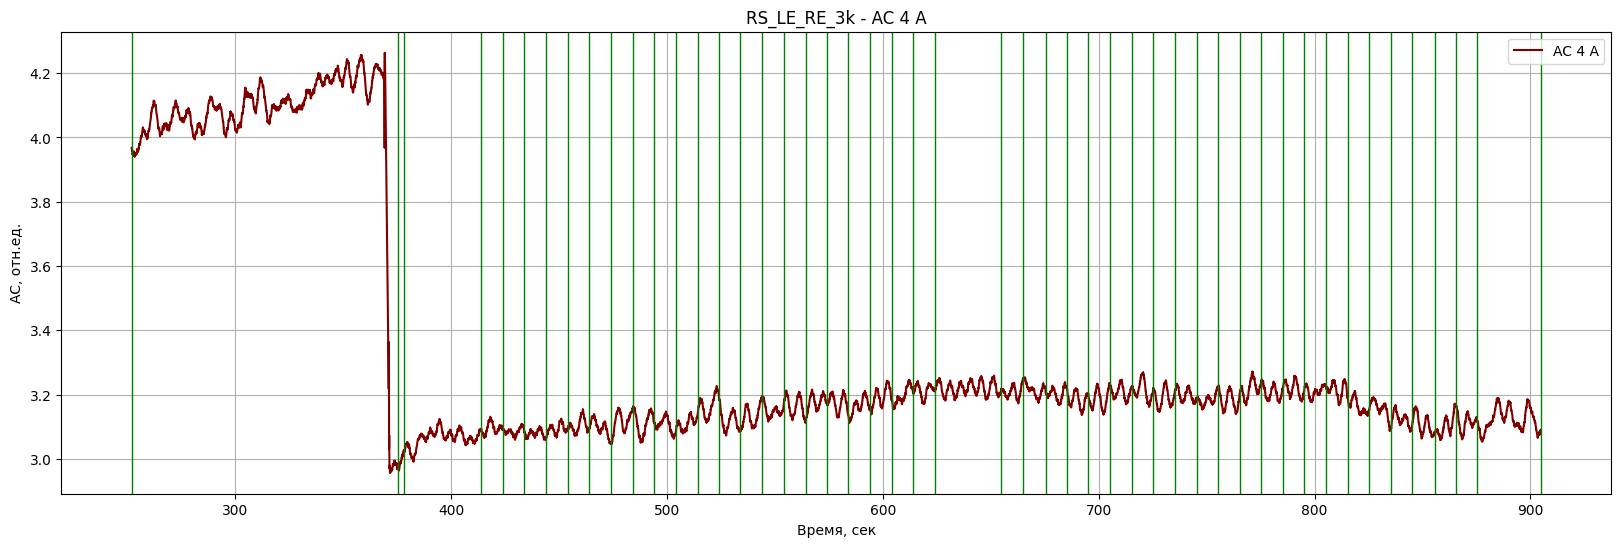

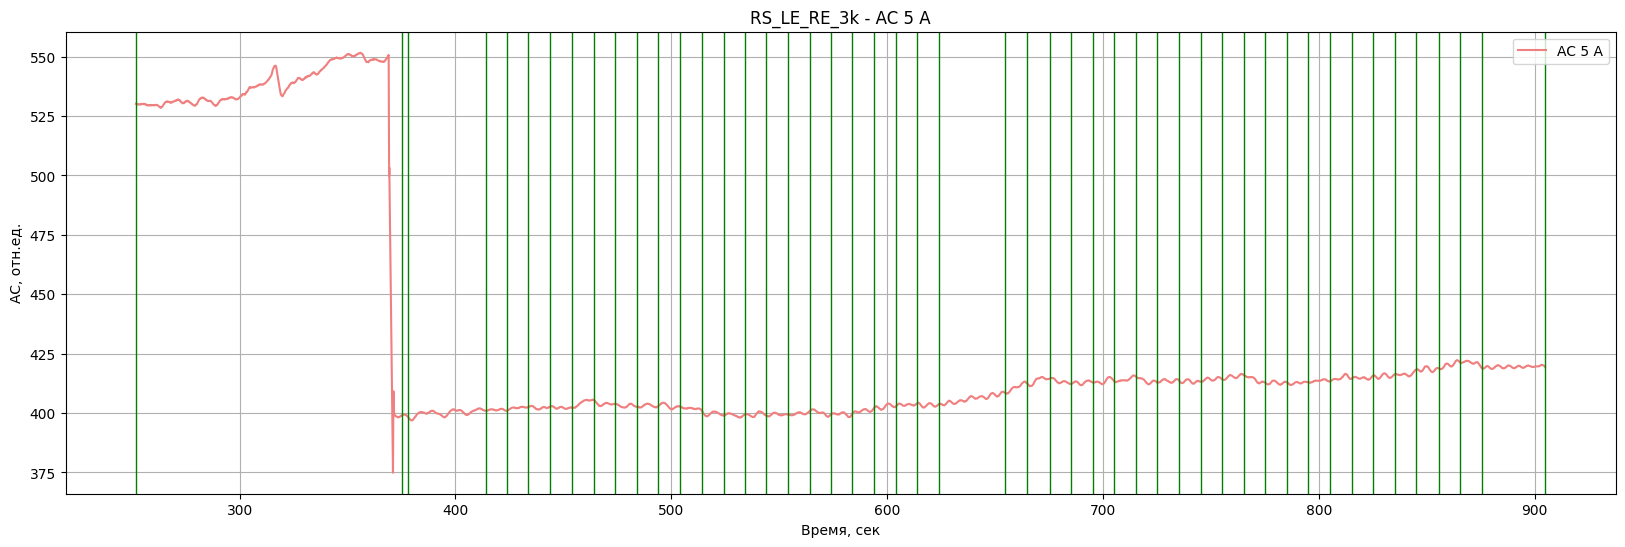

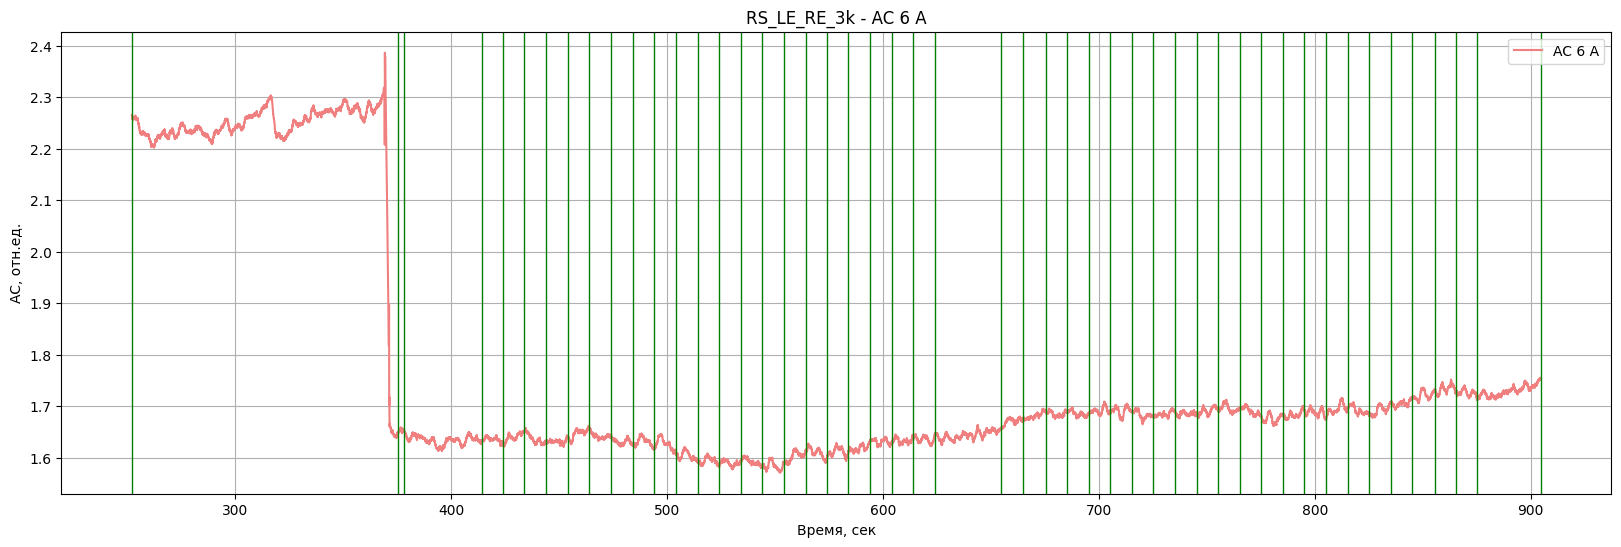

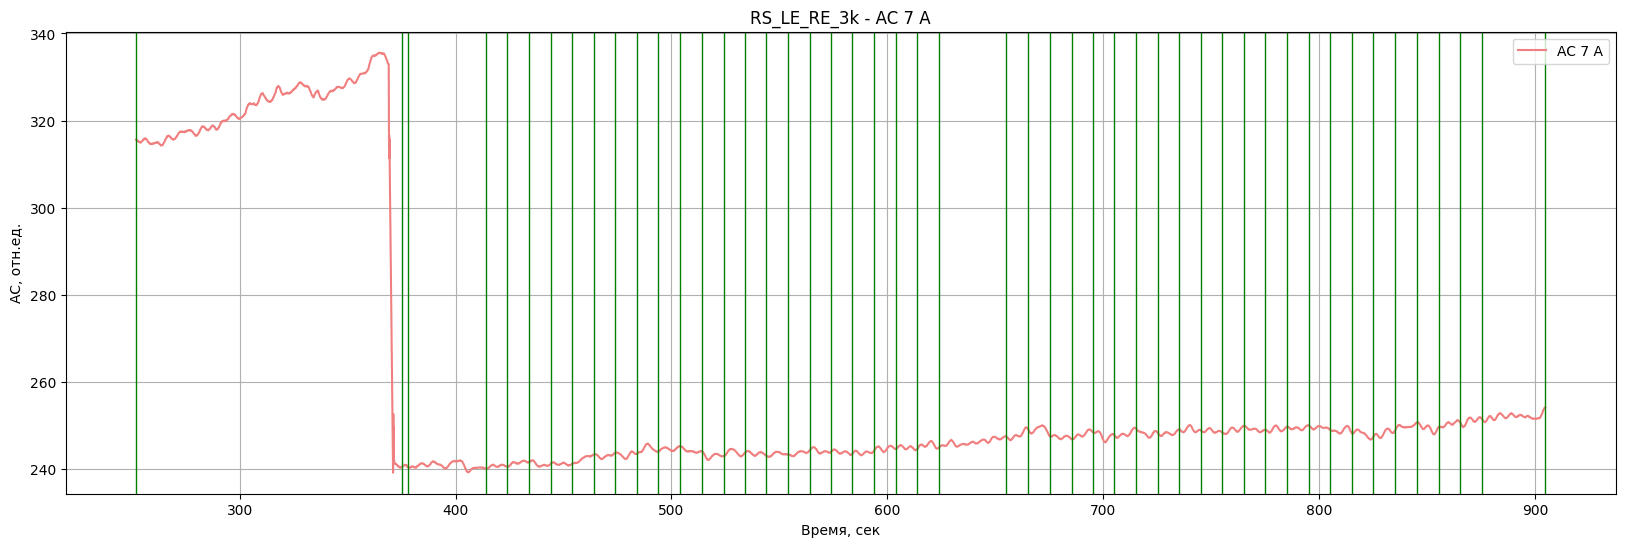

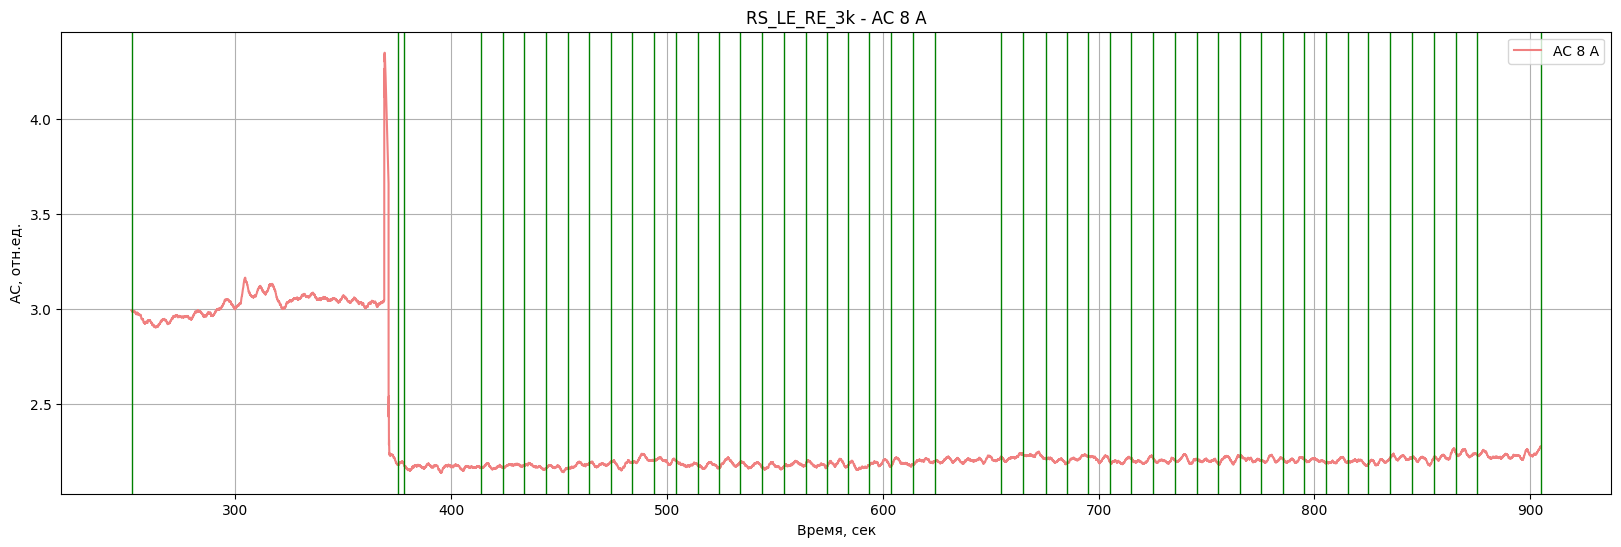

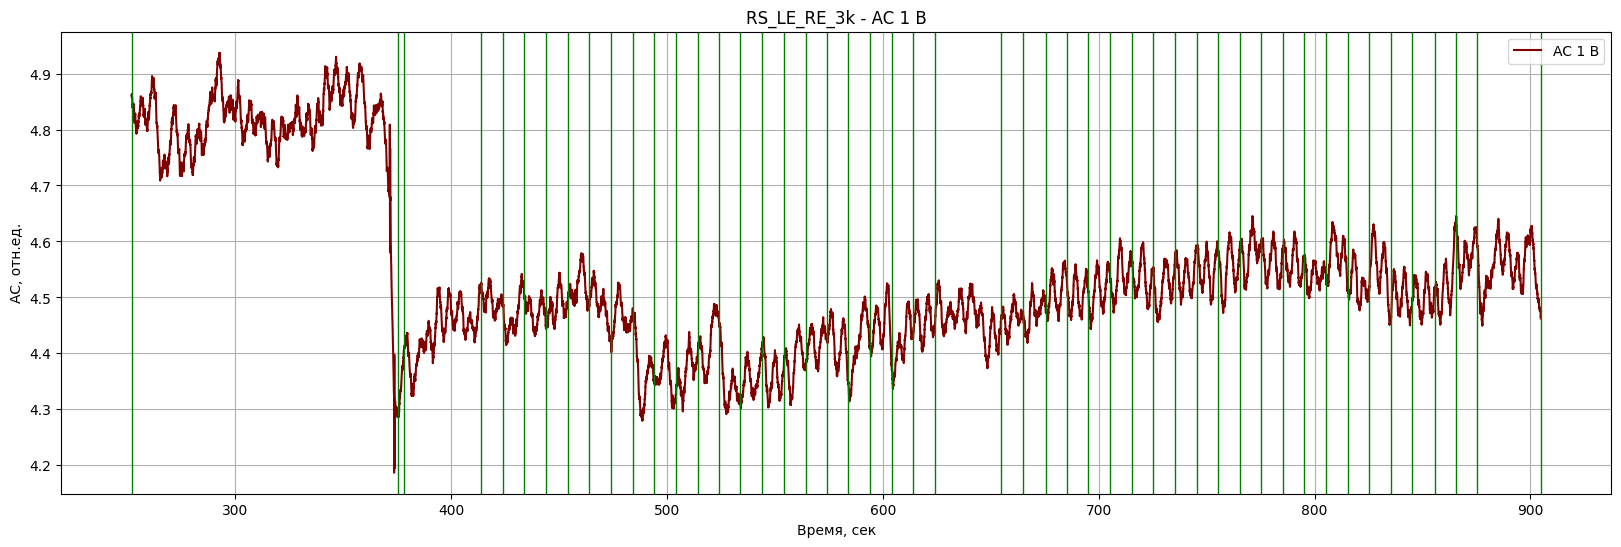

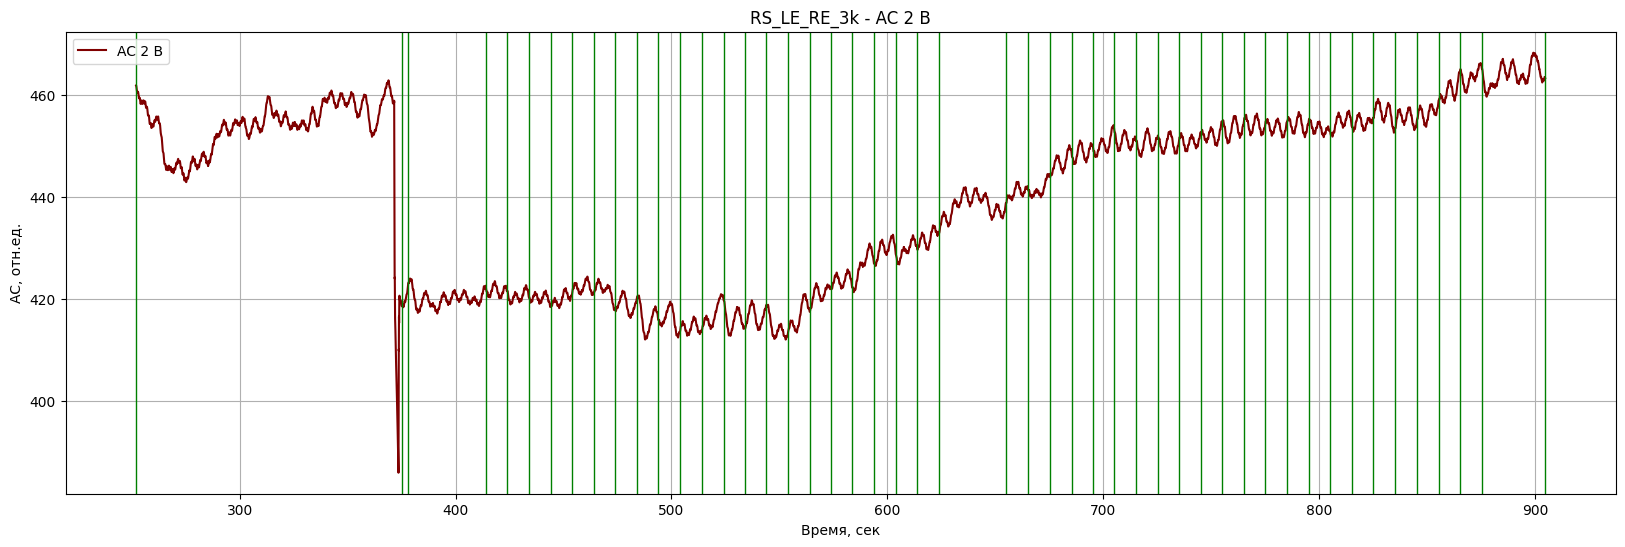

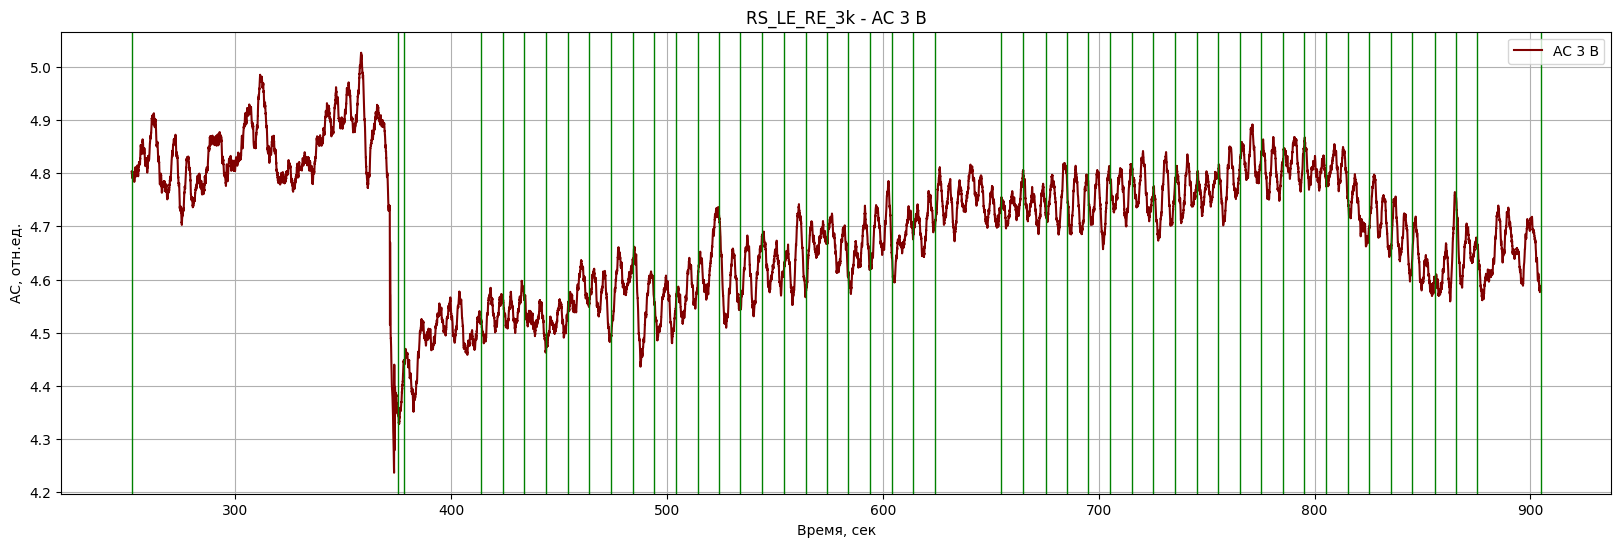

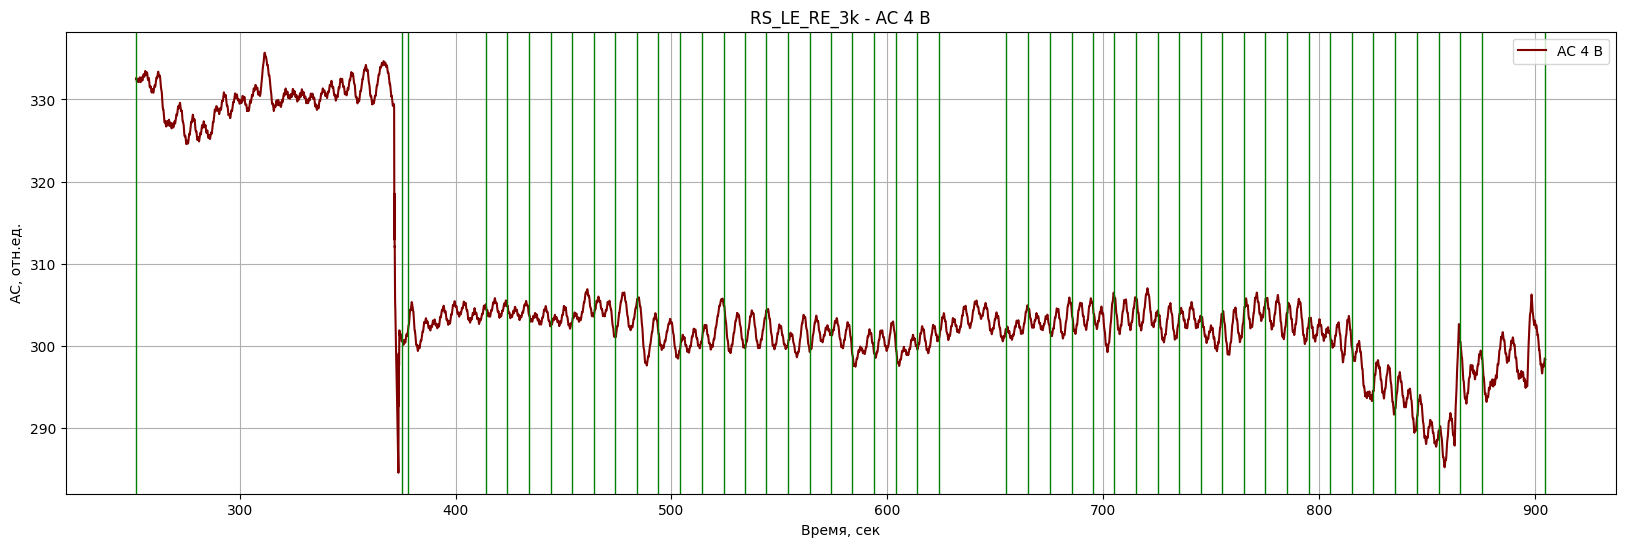

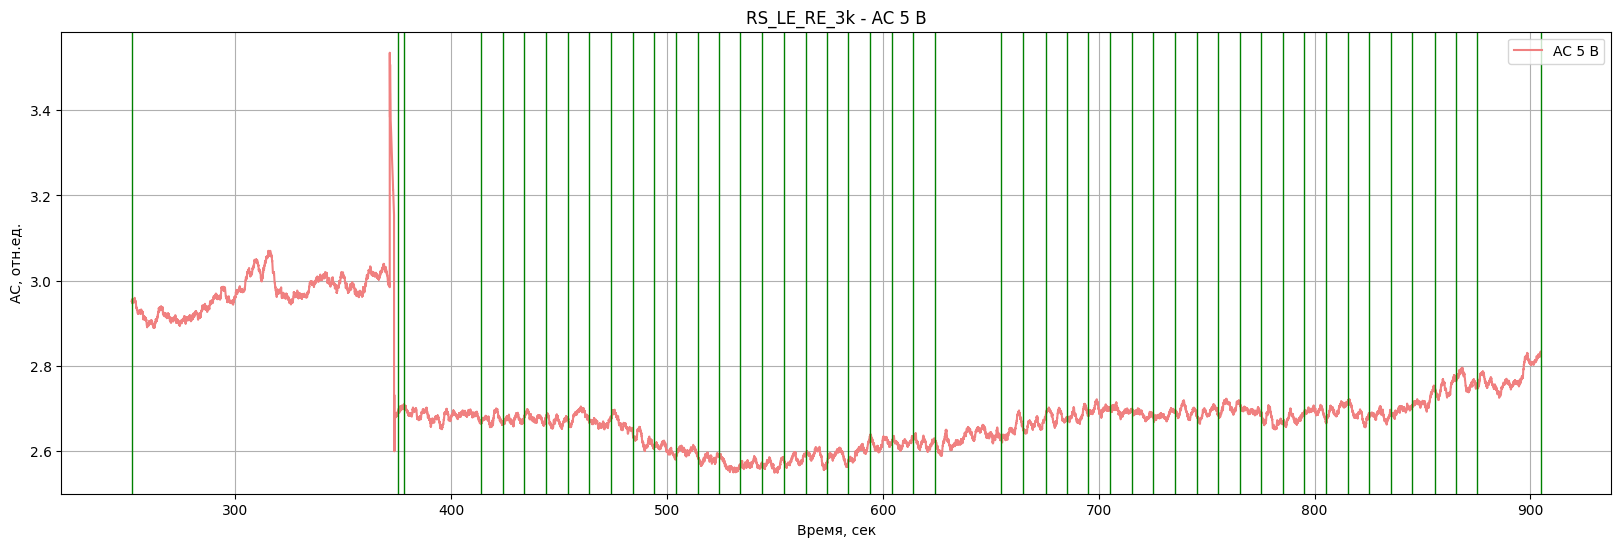

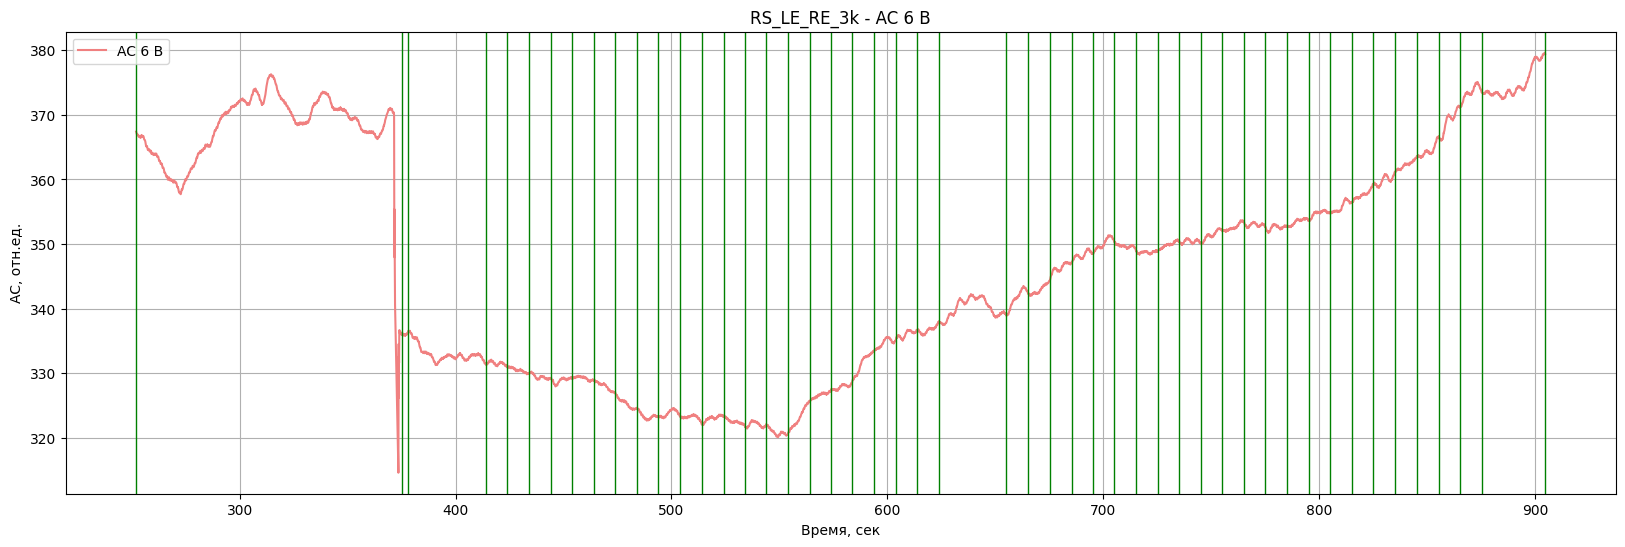

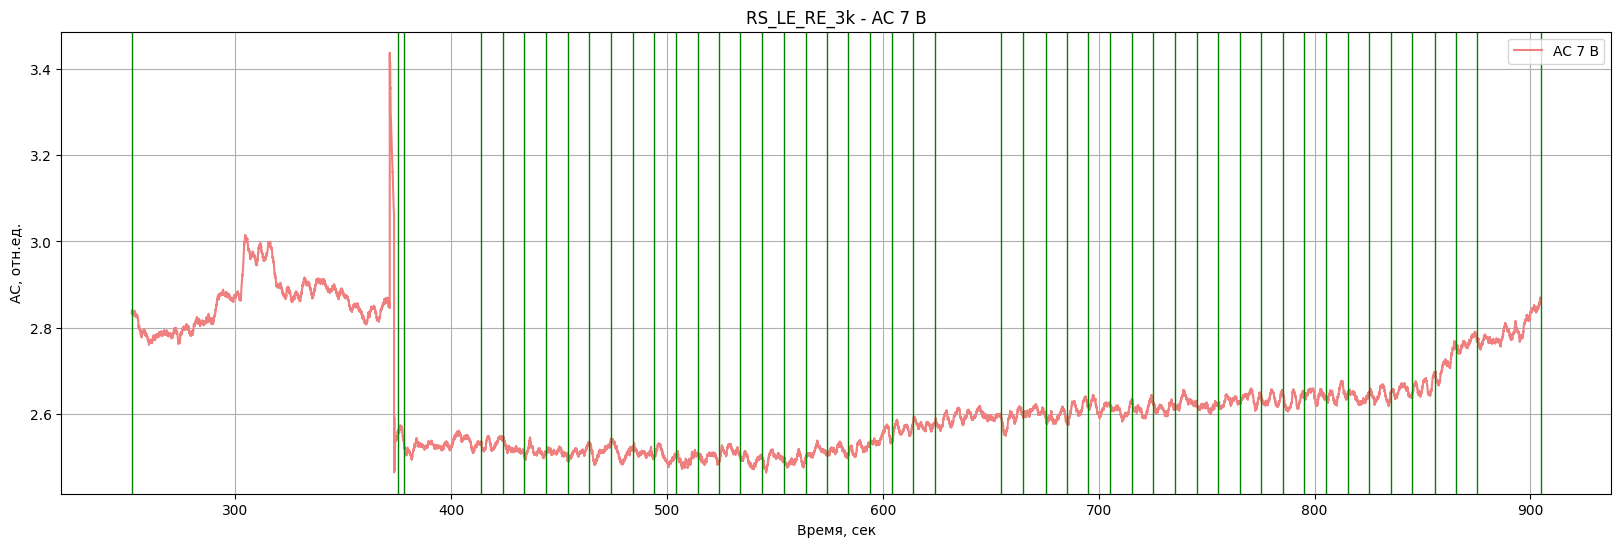

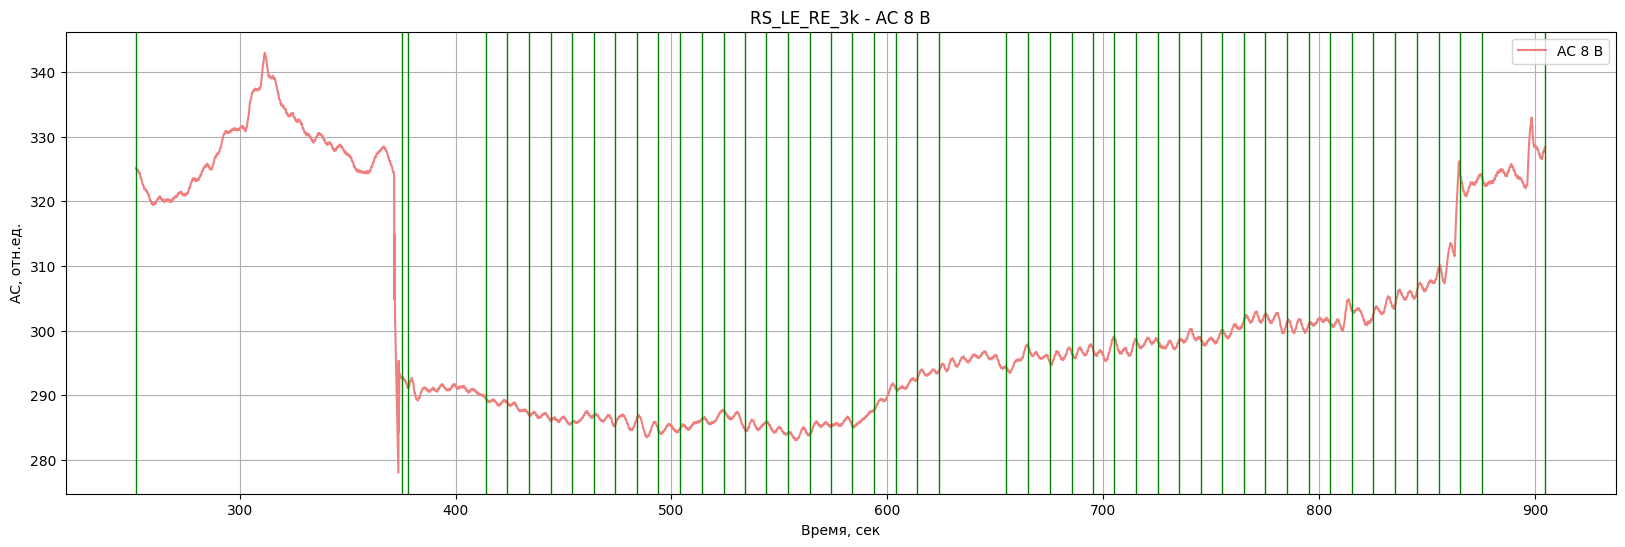

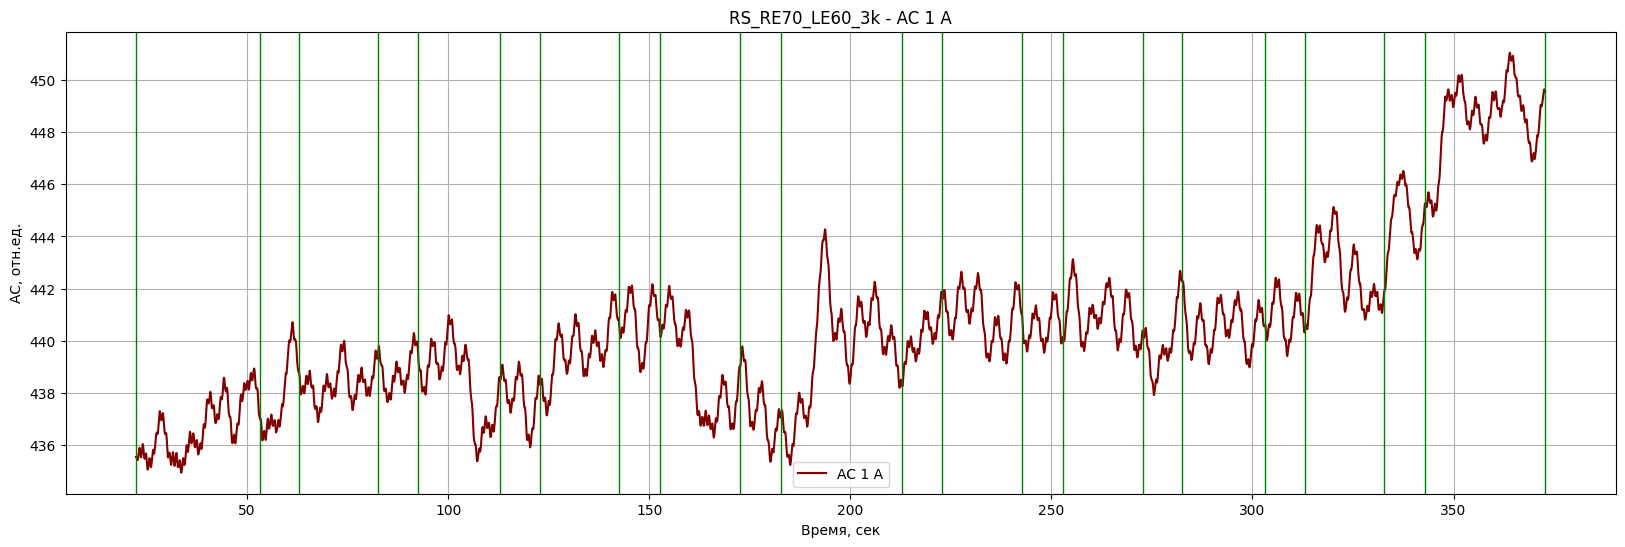

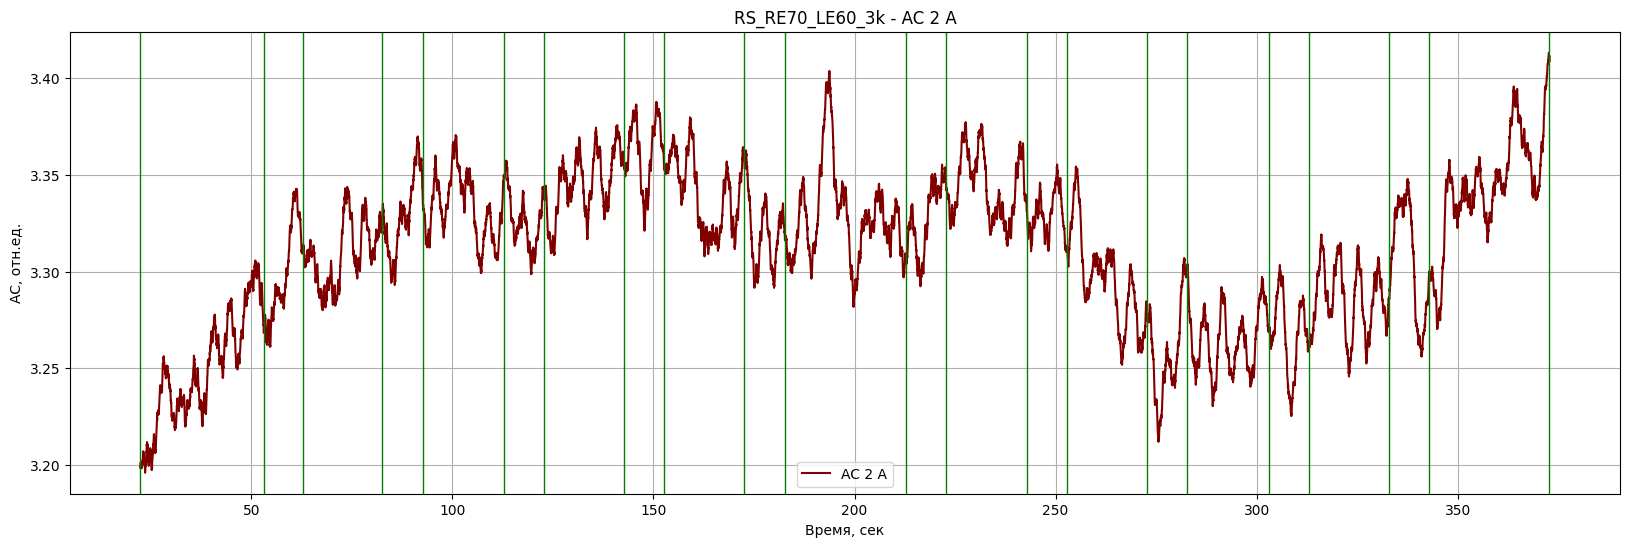

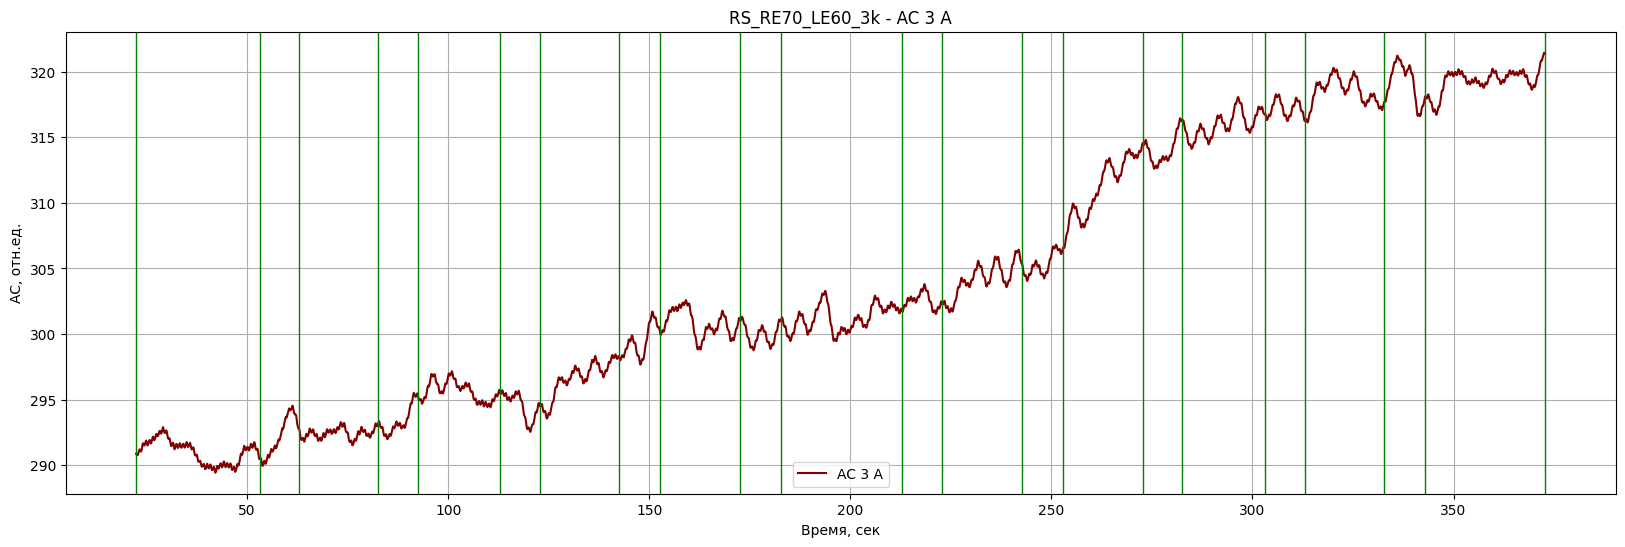

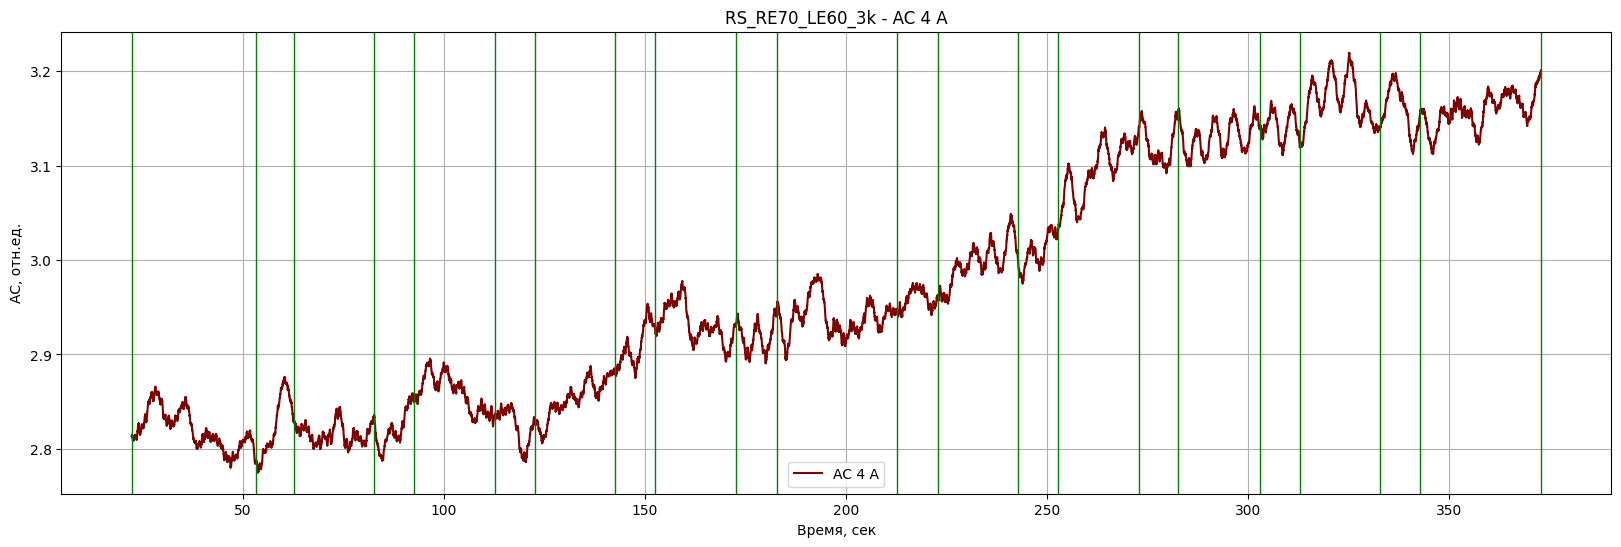

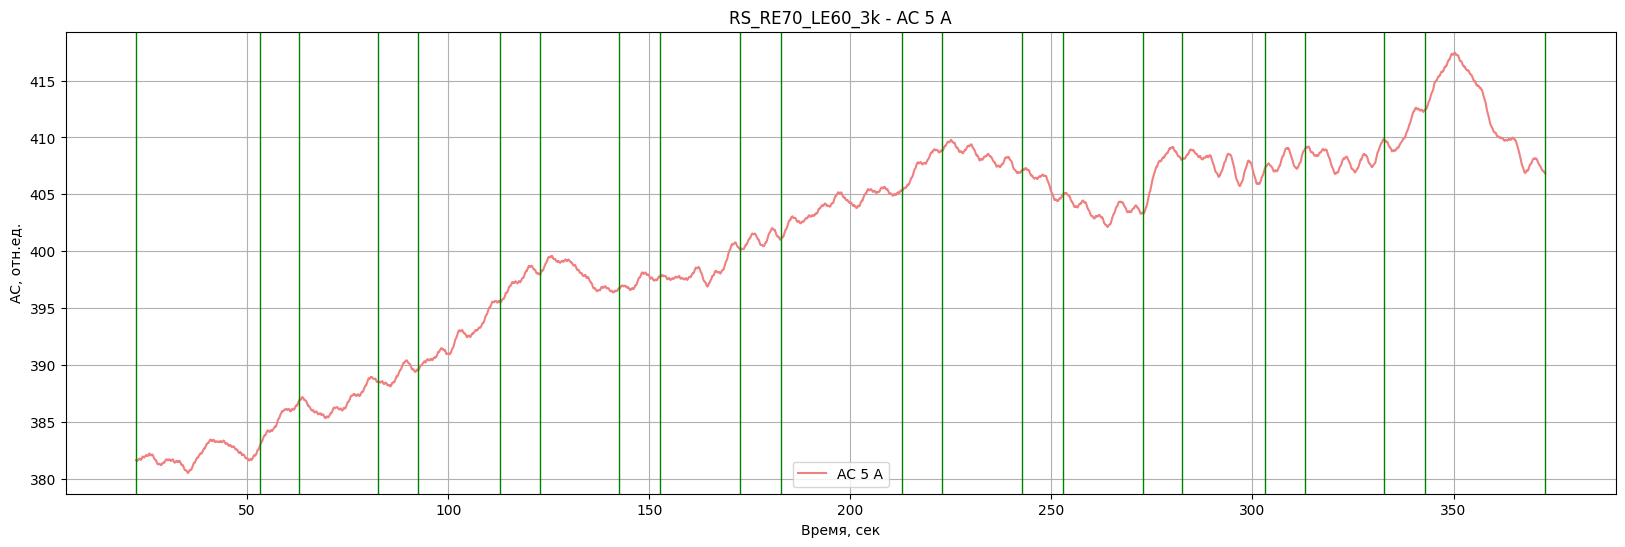

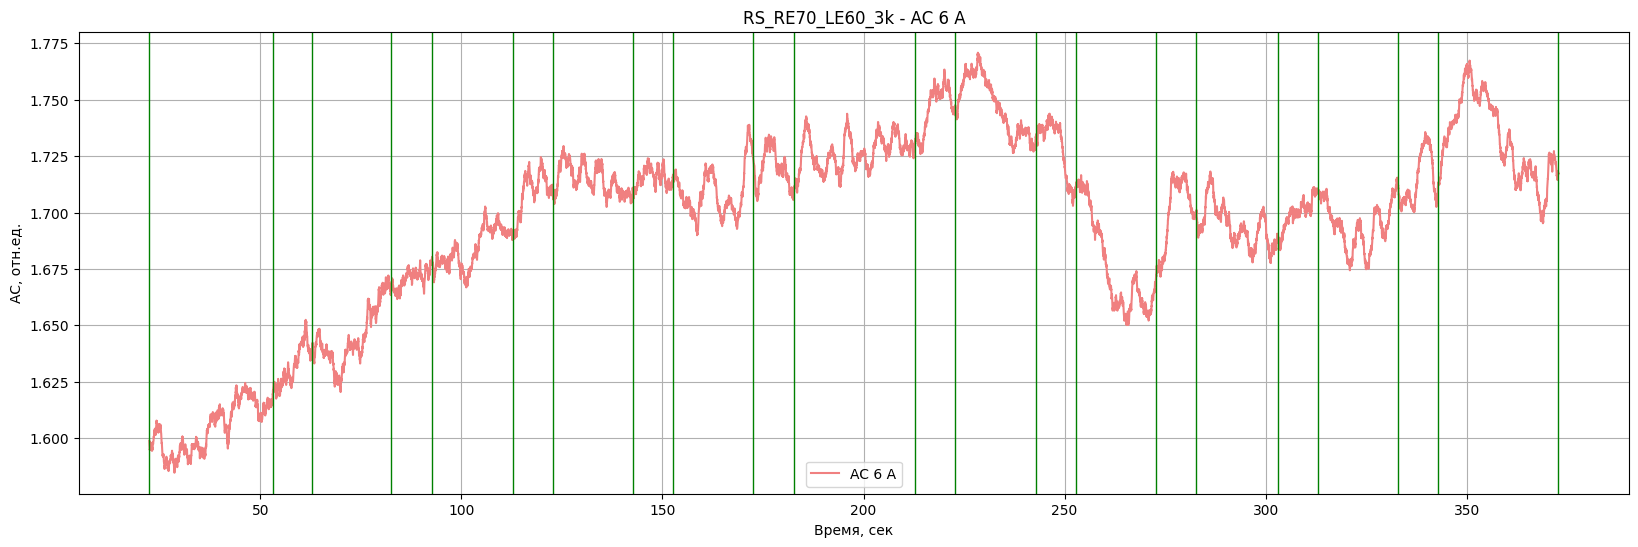

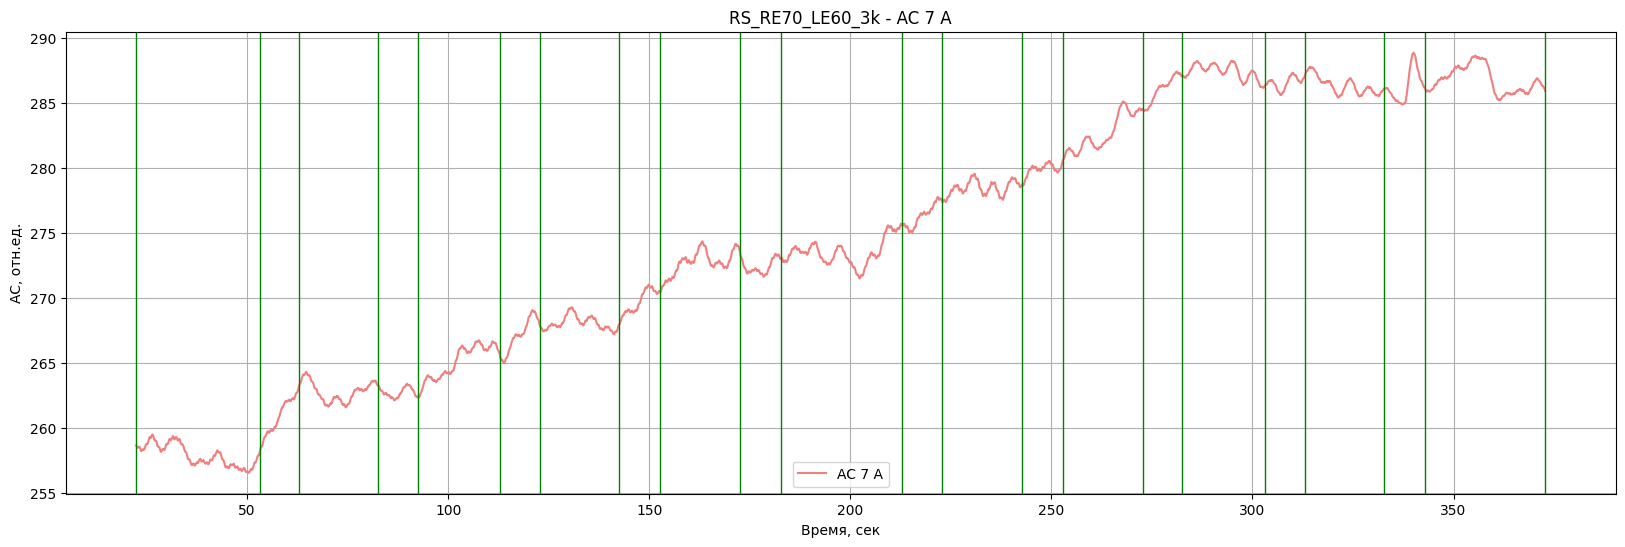

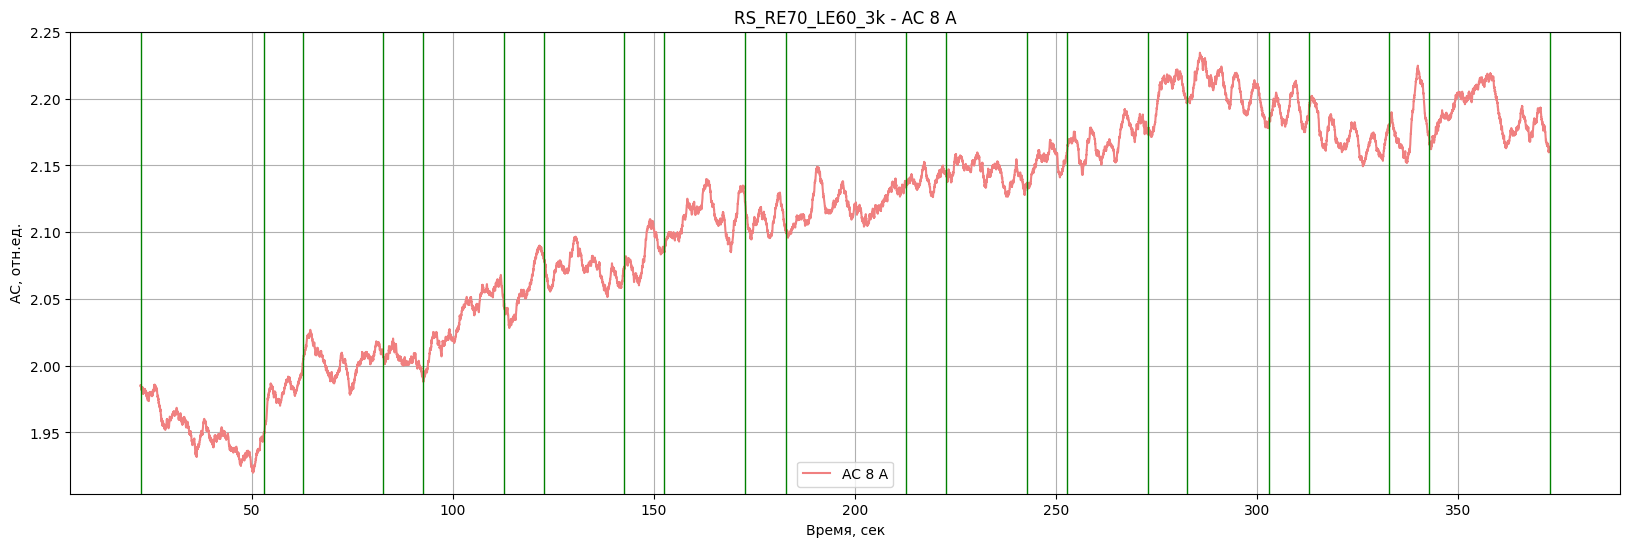

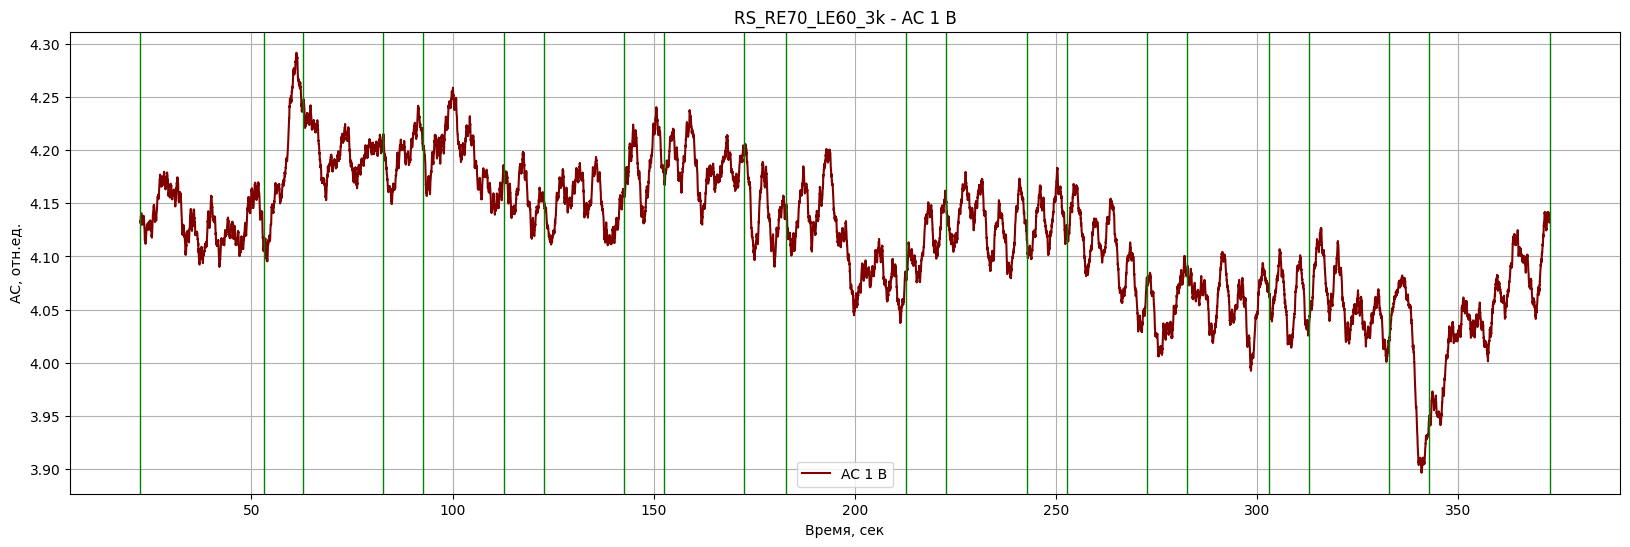

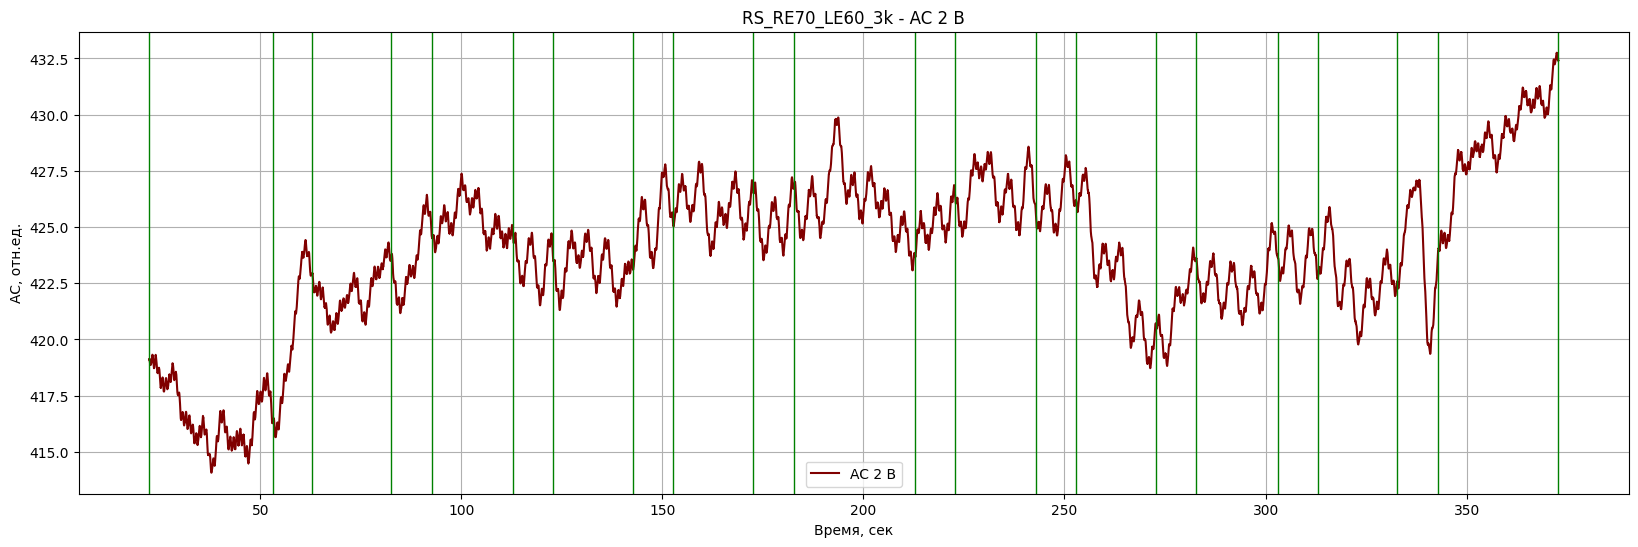

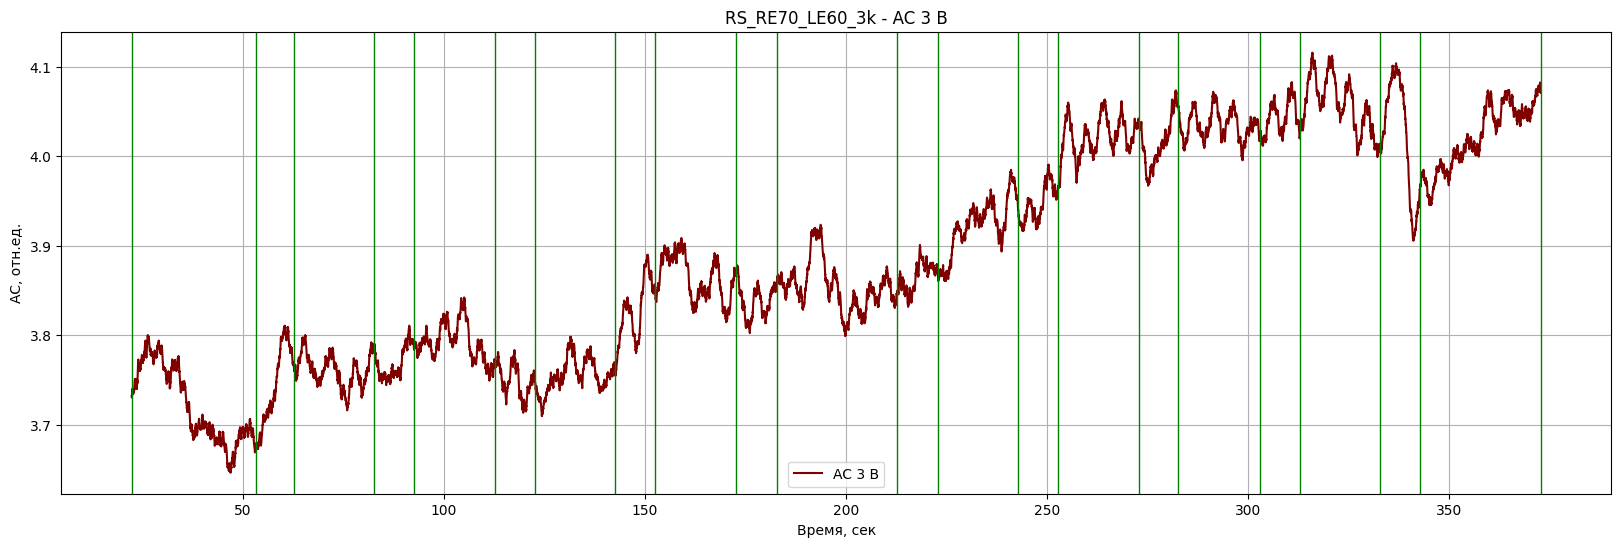

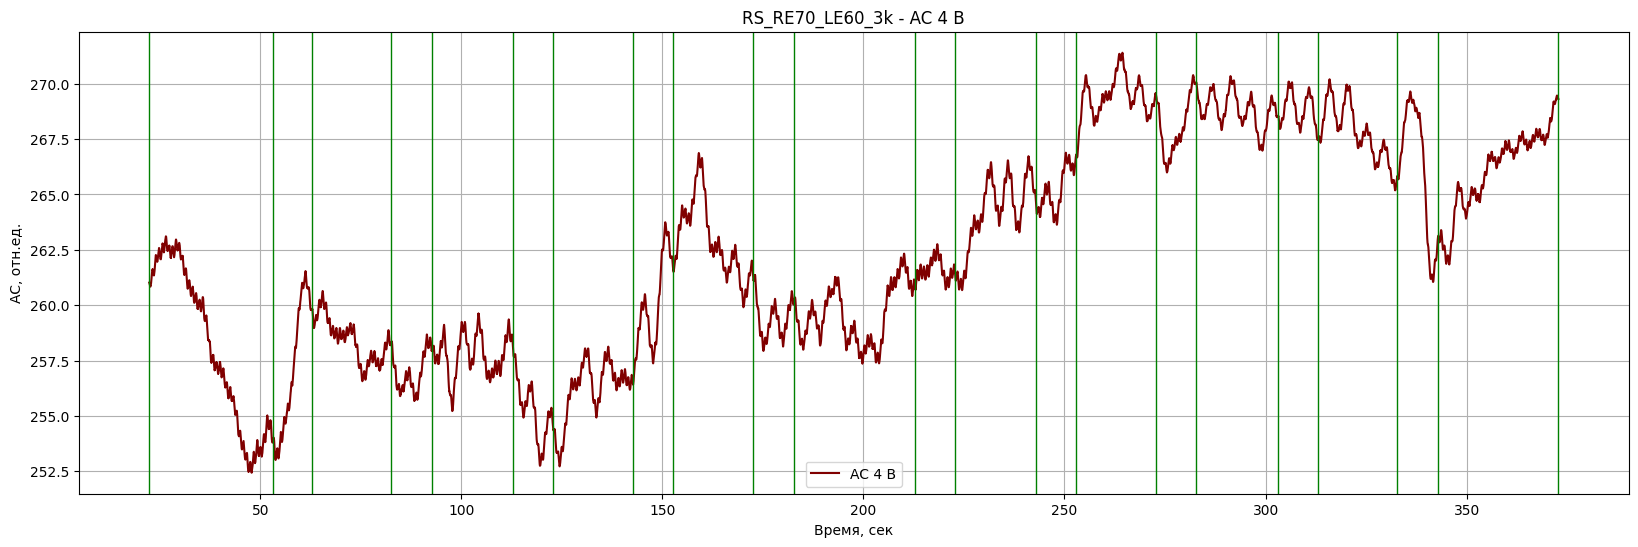

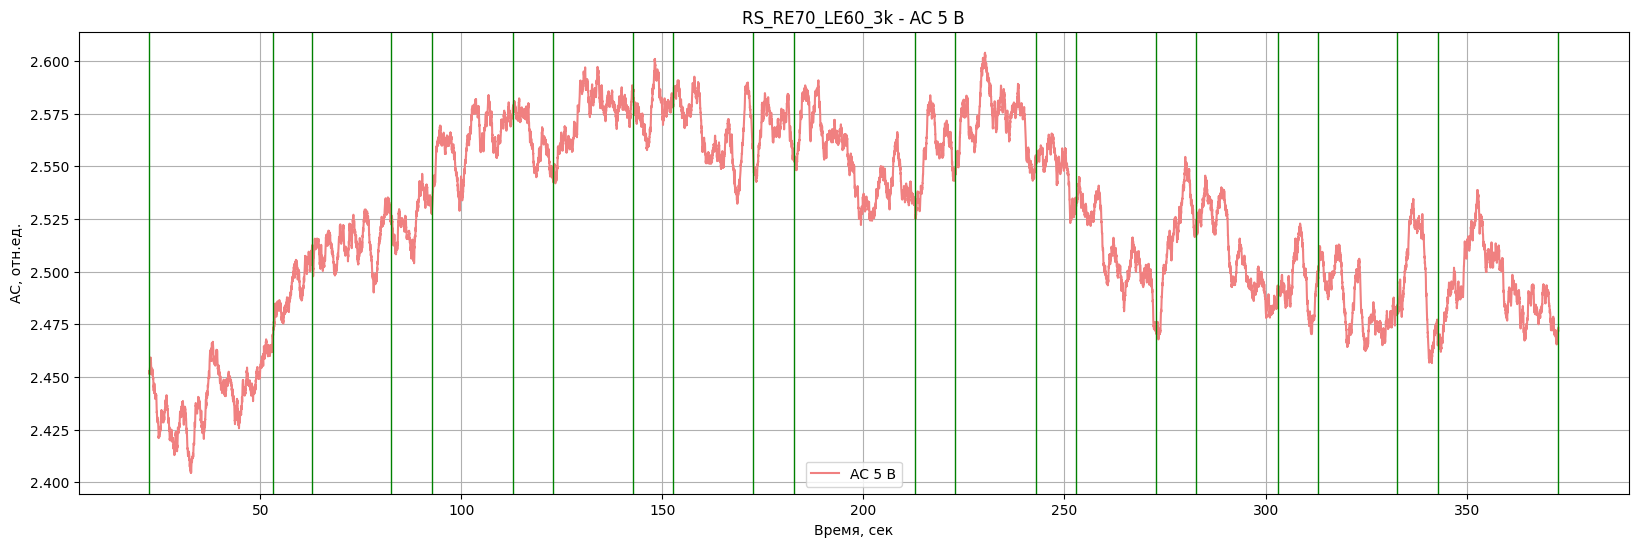

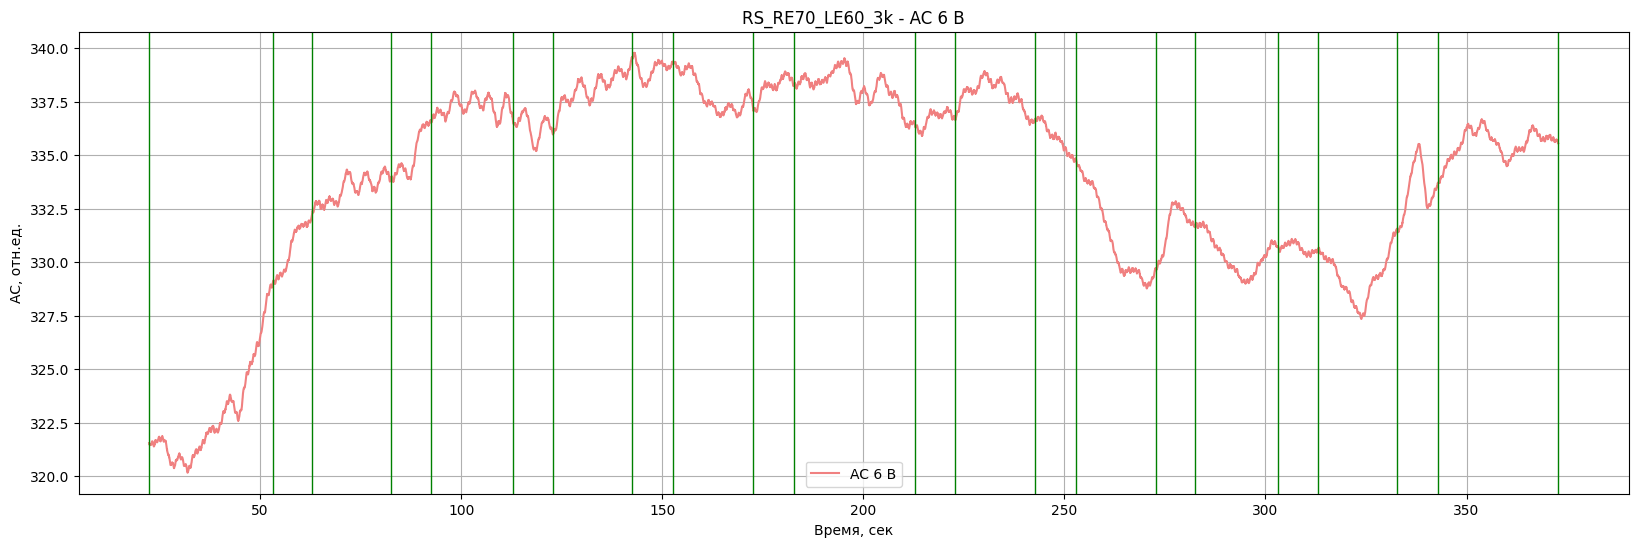

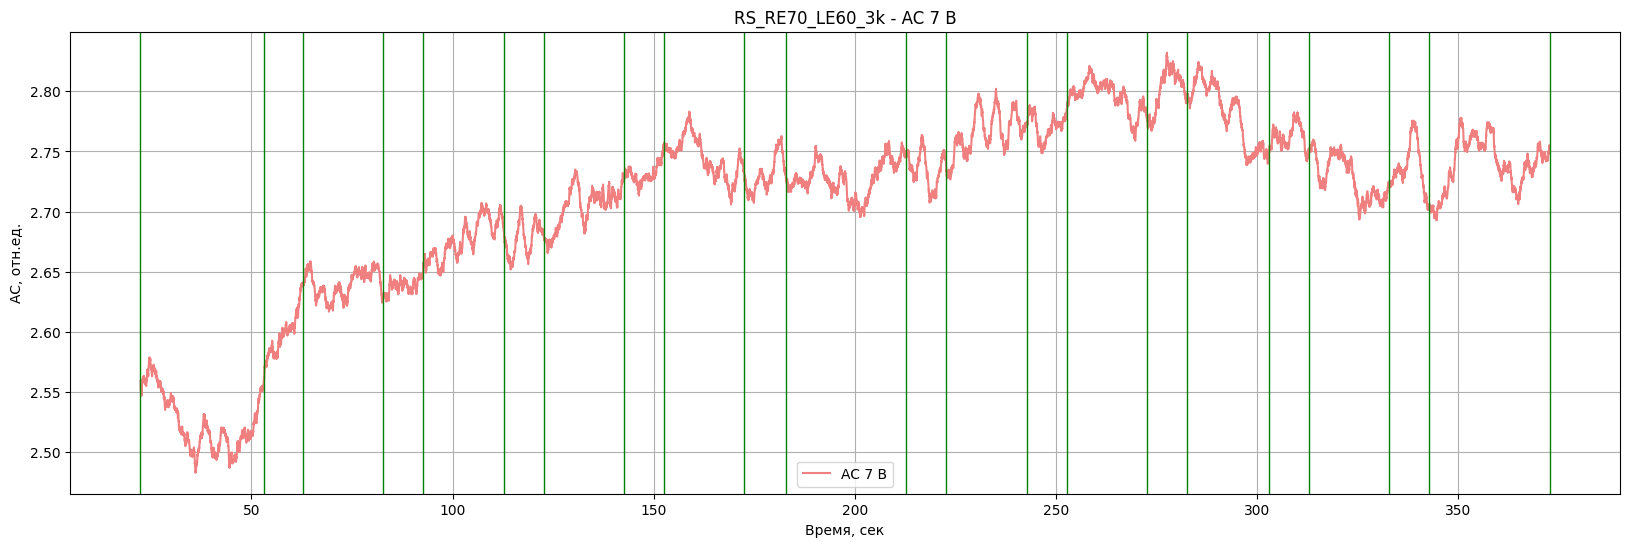

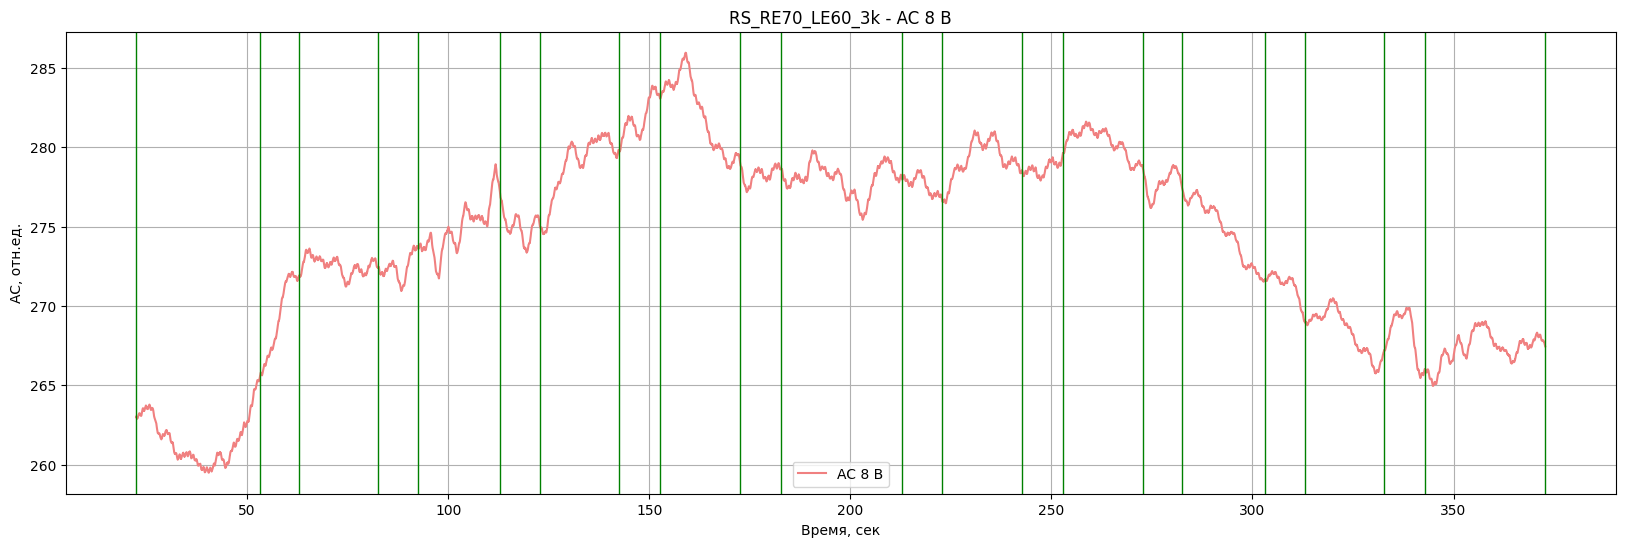

In [4]:
# Function to load data, trim, smooth, and plot for all AC channels in a given file
def plot_all_ac_intensities(file_path, title_prefix, window_size=100):
    # Load the Excel file
    df = pd.read_excel(file_path)
    
    # Define all AC channels (A and B)
    ac_channels = [f'AC {i} {ch}' for ch in ['A', 'B'] for i in range(1, 9)]
    
    # Check if required columns exist
    if 'Time' not in df.columns or 'Marker' not in df.columns or not all(ch in df.columns for ch in ac_channels):
        print(f"Required columns not found in {file_path}")
        return
    
    # Find indices of first and last non-zero markers
    markers = df[df['Marker'] != 0]
    if markers.empty:
        print(f"No non-zero markers found in {file_path}")
        return
    start_idx = df.index[df['Time'] >= markers['Time'].iloc[0]].min()
    end_idx = df.index[df['Time'] <= markers['Time'].iloc[-1]].max()
    
    # Trim the dataframe
    df = df.loc[start_idx:end_idx]
    
    # Apply smoothing (rolling mean) to all AC channels
    for channel in ac_channels:
        df[channel] = df[channel].rolling(window=window_size, center=True, min_periods=1).mean()
    
    # Plot each AC channel separately
    for channel in ac_channels:
        # Create a wide figure for each channel
        fig, ax = plt.subplots(figsize=(20, 6))  # Wide and reasonable height
        
        # Choose color based on channel number
        channel_num = int(channel.split()[1])
        color = 'maroon' if channel_num <= 4 else 'lightcoral'
        
        # Plot the smoothed AC channel vs Time
        ax.plot(df['Time'], df[channel], label=channel, color=color)
        
        # Add vertical green lines where Marker != 0 (solid line)
        markers = df[df['Marker'] != 0]
        for time in markers['Time']:
            ax.axvline(x=time, color='green', linestyle='-', linewidth=1)
        
        # Set labels and title
        ax.set_xlabel('Время, сек')
        ax.set_ylabel('AC, отн.ед.')
        ax.set_title(f'{title_prefix} - {channel}')
        ax.legend()
        ax.grid(True)
        
        # Show the plot
        plt.show()

# Plot for the first file
plot_all_ac_intensities('/kaggle/input/exp-1-2/RS_LE_RE_3k.xlsx', 'RS_LE_RE_3k')

# Plot for the second file
plot_all_ac_intensities('/kaggle/input/exp-1-2/RS_RE70_LE60_3k.xlsx', 'RS_RE70_LE60_3k')